## Look for Extremes in Todays Salish Sea compared to the Climatology 2007-2025 ##

In [1]:
import cmocean.cm as cm
import copy
import datetime as dt
from matplotlib import colormaps as matplotlib_cm
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
import xarray as xr

from salishsea_tools import visualisations, viz_tools

import importlib

In [2]:
importlib.reload(visualisations)

<module 'salishsea_tools.visualisations' from '/ocean/sallen/allen/research/Meopar/tools/SalishSeaTools/salishsea_tools/visualisations.py'>

In [3]:
plt.rcParams['font.size'] = 15
cm_haline = copy.copy(cm.haline)
cm_haline.set_bad('k')

In [4]:
mesh = xr.open_dataset('/home/sallen/MEOPAR/grid/mesh_mask202108.nc')
tmask = mesh['tmask'][0]
deptht = mesh['gdept_1d'][0]

In [5]:
salishdir = Path('/results2/SalishSea/nowcast-green.202111/')

In [6]:
# set up dates
yearrange = [2007, 2025]
thisyear = 2026
today = dt.datetime(2026, 4, 6)

In [7]:
dirstring = today.strftime("%d%b%y").lower()
timestring = f'{today.year}{today.month:02d}{today.day:02d}'
datafilen = xr.open_dataset(salishdir / dirstring /f'SalishSea_1d_{timestring}_{timestring}_grid_T.nc')
datafilenb = xr.open_dataset(salishdir / dirstring / f'SalishSea_1d_{timestring}_{timestring}_biol_T.nc')
datafilenc = xr.open_dataset(salishdir / dirstring / f'SalishSea_1d_{timestring}_{timestring}_chem_T.nc')

In [8]:
nfields = 5
file4fields = ['', '', 'b', 'b', 'c']
fields = ['vosaline', 'votemper', 'nitrate', 'silicon', 'dissolved_oxygen']
nnames = ['salinity', 'temperature', 'nitrate', 'silicon', 'oxygen']

In [9]:
# set up the subset of the spatial array to investigate
step = 1
slice_x = slice(0, 398, step)
slice_y = slice(0, 898, step)
slice_z = slice(0, 40, step)

In [10]:
nz, ny, nx = datafilen[fields[0]][0, slice_z, slice_y, slice_x].shape

In [11]:
history = np.zeros((nfields, yearrange[1] - yearrange[0] + 1, nz, ny, nx))
now = np.zeros_like(history[:, 0])

In [12]:
number_values = tmask[slice_z, slice_y, slice_x].sum(axis=2).sum(axis=1).values

In [13]:
# Thalweg
if step == 1:
    bathymetry = xr.open_dataset('/home/sallen/MEOPAR/grid/bathymetry_202108.nc', mask_and_scale=False)
    var = datafilen.vosaline[0]
    gdept = mesh.gdept_0[0].values
    lines = np.loadtxt('/home/sallen/MEOPAR/Tools/bathymetry/thalweg_working.txt', delimiter=" ", unpack=False)
    lines = lines.astype(int)
    
    thalweg_lon = mesh.nav_lon.values[lines[:,0], lines[:,1]]
    thalweg_lat = mesh.nav_lat.values[lines[:,0], lines[:,1]]
    
    dep_thal, xx_thal, var_thal = visualisations.load_thalweg(gdept, var, bathymetry.nav_lon.values,
                                                              bathymetry.nav_lat.values, lines)
    
    distance_along_thalweg = xx_thal[0, 0]
    print (dep_thal.shape)

(40, 1533)


In [14]:
def mymask(array, dl, nfields):
    maskedarray = np.ma.array(array, mask=0)
    if nfields > 1:
        for kf in range(nfields):
            maskedarray[kf] = np.ma.array(array[kf], mask=1-tmask[dl*step, ::step, ::step])
    else:
        maskedarray = np.ma.array(array, mask=1-tmask[dl*step, ::step, ::step])
    return maskedarray

In [15]:
for kf, field in enumerate(fields):
    print (field)
    if file4fields[kf] == '':
        now[kf] = datafilen[field][0, ::step, ::step, ::step]
    elif file4fields[kf] == 'b':
        now[kf] = datafilenb[field][0, ::step, ::step, ::step]
    elif file4fields[kf] == 'c':
        now[kf] = datafilenc[field][0, ::step, ::step, ::step]
datafilen.close()
datafilenb.close()
datafilenc.close()

vosaline
votemper
nitrate
silicon
dissolved_oxygen


In [16]:
for iy, year in enumerate(range(yearrange[0], yearrange[1]+1)):
    dirstring = dt.datetime(year, today.month, today.day).strftime("%d%b%y").lower()
    timestring = f'{year}{today.month:02d}{today.day:02d}'
    datafile = xr.open_dataset(salishdir / dirstring /f'SalishSea_1d_{timestring}_{timestring}_grid_T.nc')
    for kf, field in enumerate(fields):
        if file4fields[kf] == '':
            history[kf, iy] = datafile[field][0, ::step, ::step, ::step]
        datafile.close()
    datafile = xr.open_dataset(salishdir / dirstring /f'SalishSea_1d_{timestring}_{timestring}_biol_T.nc')
    for kf, field in enumerate(fields):
        if file4fields[kf] == 'b':
            history[kf, iy] = datafile[field][0, ::step, ::step, ::step]
        datafile.close()
    datafile = xr.open_dataset(salishdir / dirstring /f'SalishSea_1d_{timestring}_{timestring}_chem_T.nc')
    for kf, field in enumerate(fields):
        if file4fields[kf] == 'c':
            history[kf, iy] = datafile[field][0, ::step, ::step, ::step]
        datafile.close()

In [17]:
max_values = mymask(history.max(axis=1), np.arange(nz), nfields)
min_values = mymask(history.min(axis=1), np.arange(nz), nfields)
median_values = mymask(np.median(history, axis=1), np.arange(nz), nfields)
high_values = mymask(np.quantile(history, 0.75, axis=1), np.arange(nz), nfields)
low_values = mymask(np.quantile(history, 0.25, axis=1), np.arange(nz), nfields)

In [18]:
min_mask = now < min_values
max_mask = now > max_values
lower_mask = now < median_values
upper_mask = now > median_values
low_mask = now < low_values
high_mask = now > high_values

In [19]:
def myravel(index, nz):
    kf = index // nz
    dl = index - kf*nz
    return [kf, dl]

In [23]:
now_values = mymask(now, np.arange(nz), nfields)
extreme_high = (now_values - max_values) / (high_values - low_values)
extreme_high.mask[extreme_high <= 0] = True
how_extreme_high = extreme_high.count(axis=3).sum(axis=2)/(number_values+0.001)
zmaxhigh = myravel(np.argmax(how_extreme_high), nz)

extreme_low = (min_values - now_values) / (high_values - low_values)
extreme_low.mask[extreme_low <= 0] = True
how_extreme_low = extreme_low.count(axis=3).sum(axis=2)/(number_values+0.001)
zmaxlow = myravel(np.argmax(how_extreme_low), nz)

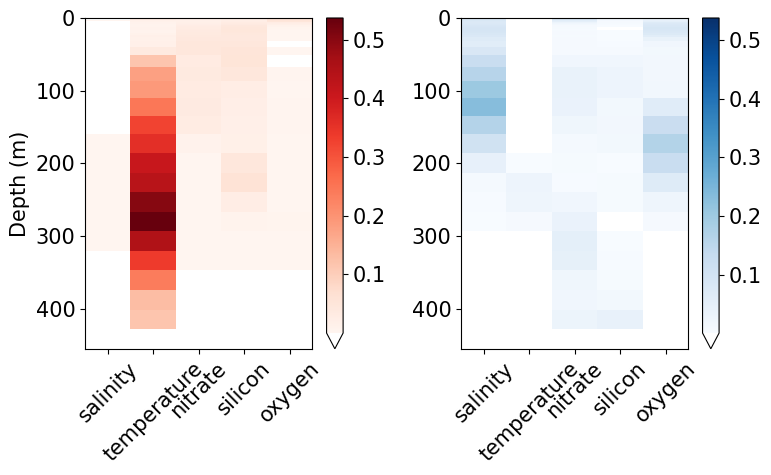

In [24]:
vmax = max(how_extreme_high.max(), how_extreme_low.max())

fig, axs = plt.subplots(1, 2, figsize=(8, 5))
cmap1 = matplotlib_cm['Reds'].copy()
cmap1.set_under('w')
colours = axs[0].pcolormesh(np.arange(nfields), deptht[np.arange(nz)*step].values,
                            how_extreme_high.transpose(), cmap=cmap1, vmin=0.0001, vmax=vmax)
fig.colorbar(colours, ax=axs[0], extend='min')

cmap1 = matplotlib_cm['Blues'].copy()
cmap1.set_under('w')
colours = axs[1].pcolormesh(np.arange(nfields), deptht[np.arange(nz)*step].values,
                            how_extreme_low.transpose(), cmap=cmap1, vmin=0.001, vmax=vmax)
fig.colorbar(colours, ax=axs[1], extend='min')

for ax in axs:
    ax.invert_yaxis()
    ax.set_xticks(np.arange(nfields), nnames, rotation=45)

axs[0].set_ylabel('Depth (m)')
fig.tight_layout();

[0, 27]


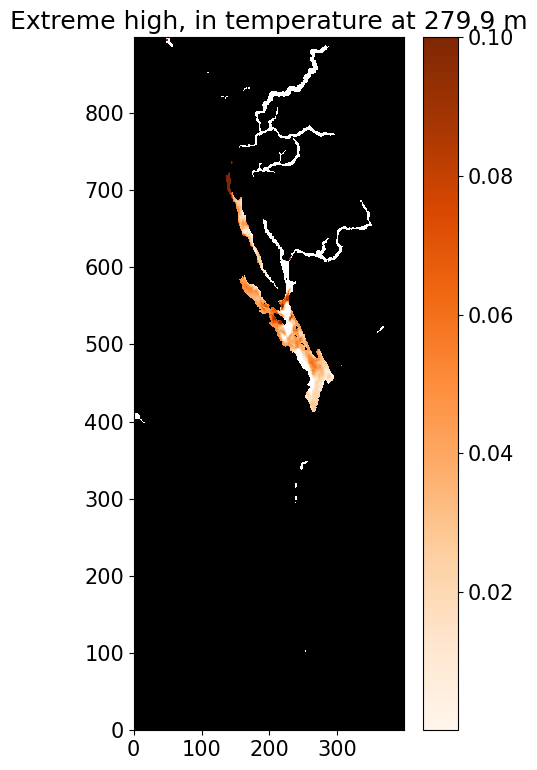

In [28]:
print (zmaxlow)
if how_extreme_high[zmaxhigh[0], zmaxhigh[1]] > how_extreme_low[zmaxlow[0], zmaxlow[1]]:
    extreme = 'high'
else:
    extreme = 'low'
    
fig, ax = plt.subplots(1, 1, figsize=(5, 9))
if extreme == 'low':
    ax.pcolormesh(tmask[zmaxlow[1]*step, ::step, ::step], cmap='binary_r')
    colours = ax.pcolormesh(extreme_low[zmaxlow[0], zmaxlow[1]], cmap='Oranges')
else:
    ax.pcolormesh(tmask[zmaxhigh[1]*step, ::step, ::step], cmap='binary_r')
    colours = ax.pcolormesh(extreme_high[zmaxhigh[0], zmaxhigh[1]], cmap='Oranges', vmax=0.1)
fig.colorbar(colours, ax=ax)
viz_tools.set_aspect(ax);
if extreme == 'low':
    dl = zmaxlow[1]
    kf = zmaxlow[0]
else:
    dl = zmaxhigh[1]
    kf = zmaxhigh[0]
ax.set_title(f'Extreme {extreme}, in {nnames[kf]} at {deptht[dl*step].values:.1f} m');

In [38]:
if step == 1:
    meshgrid = xr.open_dataset('/home/sallen/MEOPAR/grid/mesh_mask202108.nc')
    bathymetry = xr.open_dataset('/home/sallen/MEOPAR/grid/bathymetry_202108.nc')
    
def contour_plot(kf):
    fig, ax = plt.subplots(1, 1, figsize=(15,5))
    visualisations.contour_thalweg(ax, now[kf] - median_values[kf], bathymetry, meshgrid, 
                                   clevels=[-1, -0.75, -0.5, -0.25, 0, 0.25, 0.5, 0.75, 1], 
          #                         clevels=np.arange(-0.1, 0.11, 0.01),
                                   cmap='bwr', xcoord_distance=True);
    ax.set_title(f'{nnames[kf]}, now - median values')
#    ax.set_xlim(700, None)

/ocean/sallen/allen/research/Meopar/tools/SalishSeaTools/salishsea_tools/visualisations.py:257: UserWarning: Warning: converting a masked element to nan.
  newvar[level, i] = variable[level - 1, i]


(40, 1533) (40, 1533) (40, 1533)


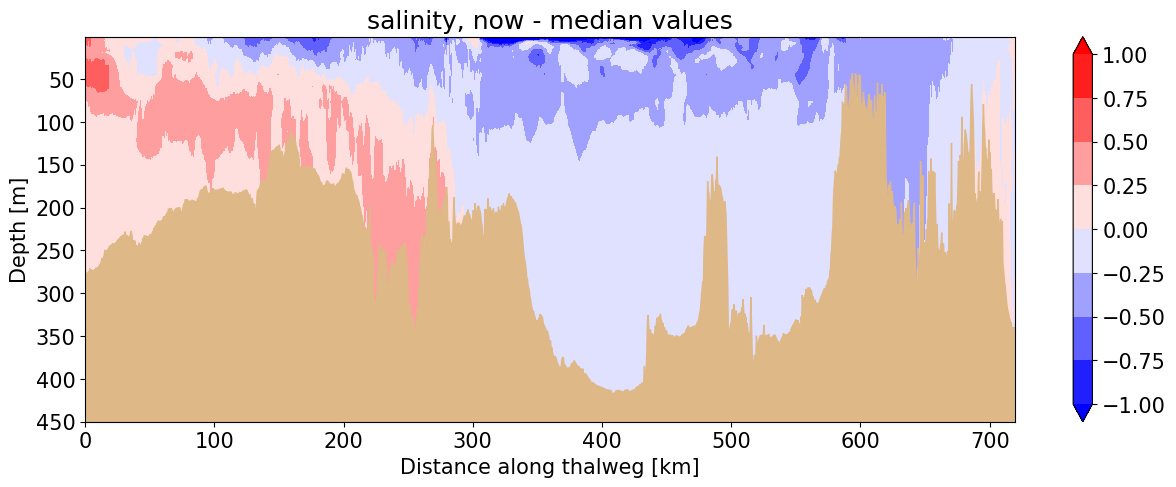

In [39]:
if step == 1: contour_plot(0)

(40, 1533) (40, 1533) (40, 1533)


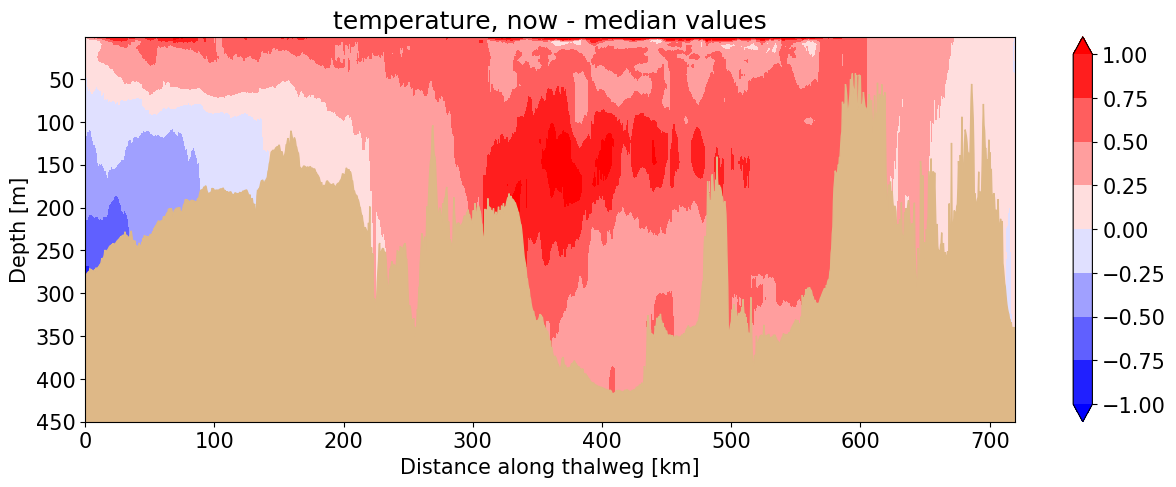

In [40]:
if step == 1: contour_plot(1)

In [41]:
def nine_plot(kf, dl):
    fig, axs = plt.subplots(3, 3, figsize=(15, 27))
    field = fields[kf]
    fig.suptitle(f'Depth is {deptht[dl*step].values:.1f} m and field is {nnames[kf]}')
    
    if field == 'vosaline':
        cmap = cm.haline
    elif field == 'votemper':
        cmap = cm.thermal
    
    alpha = 0.25
    needed = max_values[kf, dl]
    vmax = np.nanmax(needed[needed !=0])
    needed = min_values[kf, dl]
    vmin = np.nanmin(needed[needed !=0])
    
    for ax in axs.flatten():
        ax.pcolormesh(tmask[dl*step, ::step, ::step], cmap='binary_r')
    
    # First Row
    colours = axs[0, 0].pcolormesh(mymask(max_values[kf, dl], dl, 1), vmin=vmin, vmax=vmax, cmap=cmap)
    fig.colorbar(colours, ax=axs[0, 0]);
    axs[0, 0].set_title('Maximum Values')
    
    colours = axs[0, 1].pcolormesh(mymask(min_values[kf, dl], dl, 1), vmin=vmin, vmax=vmax, cmap=cmap)
    fig.colorbar(colours, ax=axs[0, 1]);
    axs[0, 1].set_title('Minimum Values')
    
    colours = axs[0, 2].pcolormesh(mymask(now[kf, dl], dl, 1), vmin=vmin, vmax=vmax, cmap=cmap)
    fig.colorbar(colours, ax=axs[0, 2])
    axs[0, 2].set_title(f'{today}')
    
    # Second Row
    colours = axs[1, 0].pcolormesh(np.ma.array(now[kf, dl], mask=1-upper_mask[kf, dl]), vmin=vmin, vmax=vmax, cmap=cmap)
    axs[1, 0].pcolormesh(mymask(now[kf, dl], dl, 1), vmax=vmax, cmap=cmap, alpha=alpha)
    fig.colorbar(colours, ax=axs[1, 0])
    axs[1, 0].set_title('Above Median')

    axs[1, 1].pcolormesh(now[kf, dl], vmax=vmax, alpha=alpha, cmap=cmap)
    colours = axs[1, 1].pcolormesh(np.ma.array(now[kf, dl], mask=1-high_mask[kf, dl]), vmin=vmin, vmax=vmax, cmap=cmap)
    fig.colorbar(colours, ax=axs[1, 1])
    axs[1, 1].set_title('Upper Quartile')
    
    axs[1, 2].pcolormesh(now[kf, dl], vmax=vmax, alpha=alpha, cmap=cmap)
    colours = axs[1, 2].pcolormesh(np.ma.array(now[kf,dl],mask=1-max_mask[kf, dl]), vmin=vmin, vmax=vmax, cmap=cmap)
    axs[1, 2].set_title('New Maximum');
    fig.colorbar(colours, ax=axs[1, 2]);
    
    # Third Row
    axs[2, 0].pcolormesh(mymask(now[kf,dl], dl, 1), vmax=vmax, cmap=cmap, alpha=alpha)
    colours = axs[2, 0].pcolormesh(np.ma.array(now[kf, dl],mask=1-lower_mask[kf, dl]), vmin=vmin, vmax=vmax, cmap=cmap)
    fig.colorbar(colours, ax=axs[2, 0])
    axs[2, 0].set_title('Below Median')
    
    axs[2, 1].pcolormesh(now[kf, dl], vmax=vmax, alpha=alpha, cmap=cmap)
    colours = axs[2, 1].pcolormesh(np.ma.array(now[kf, dl], mask=1-low_mask[kf, dl]), vmin=vmin, vmax=vmax, cmap=cmap)
    fig.colorbar(colours, ax=axs[2, 1])
    axs[2, 1].set_title('Lower Quartile')
    
    axs[2, 2].pcolormesh(now[kf, dl], vmax=vmax, alpha=alpha, cmap=cmap)
    colours = axs[2, 2].pcolormesh(np.ma.array(now[kf,dl],mask=1-min_mask[kf, dl]), vmin=vmin, vmax=vmax, cmap=cmap)
    axs[2, 2].set_title('New Minimum');
    fig.colorbar(colours, ax=axs[2, 2]);
    
    for ax in axs.flatten():
            viz_tools.set_aspect(ax)

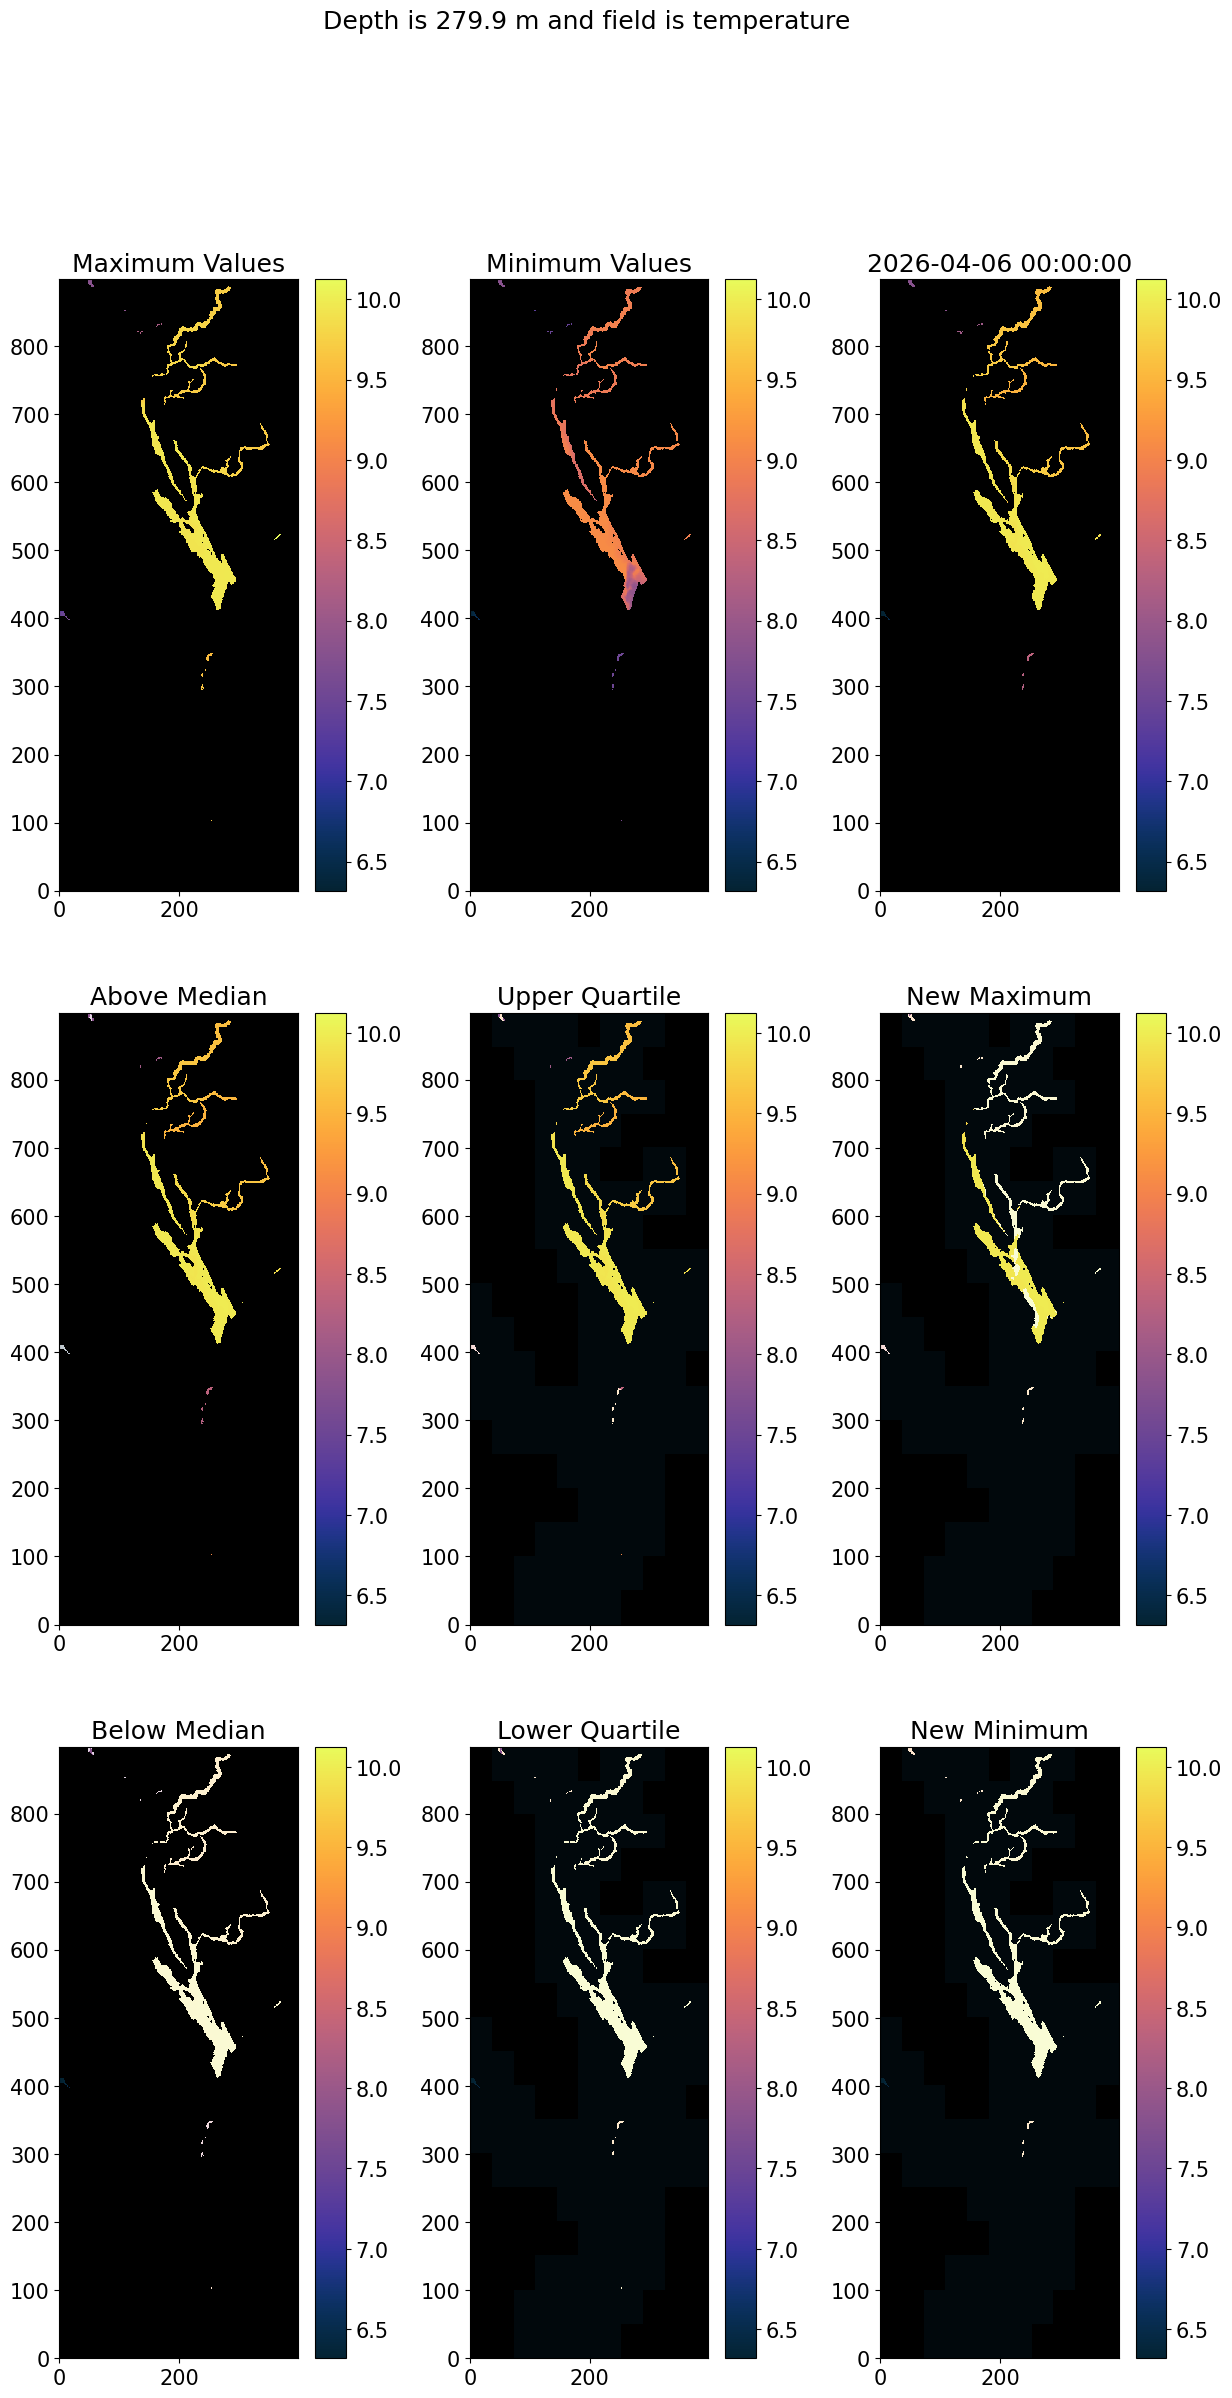

In [42]:
if extreme == 'low':
    dl = zmaxlow[1]
    kf = zmaxlow[0]
else:
    dl = zmaxhigh[1]
    kf = zmaxhigh[0]

field = fields[kf]
if field == 'vosaline':
    cmap = cm.haline
elif field == 'votemper':
    cmap = cm.thermal

needed = max_values[kf, dl]
vmax = np.nanmax(needed[needed !=0])
needed = min_values[kf, dl]
vmin = np.nanmin(needed[needed !=0])
nine_plot(kf, dl)

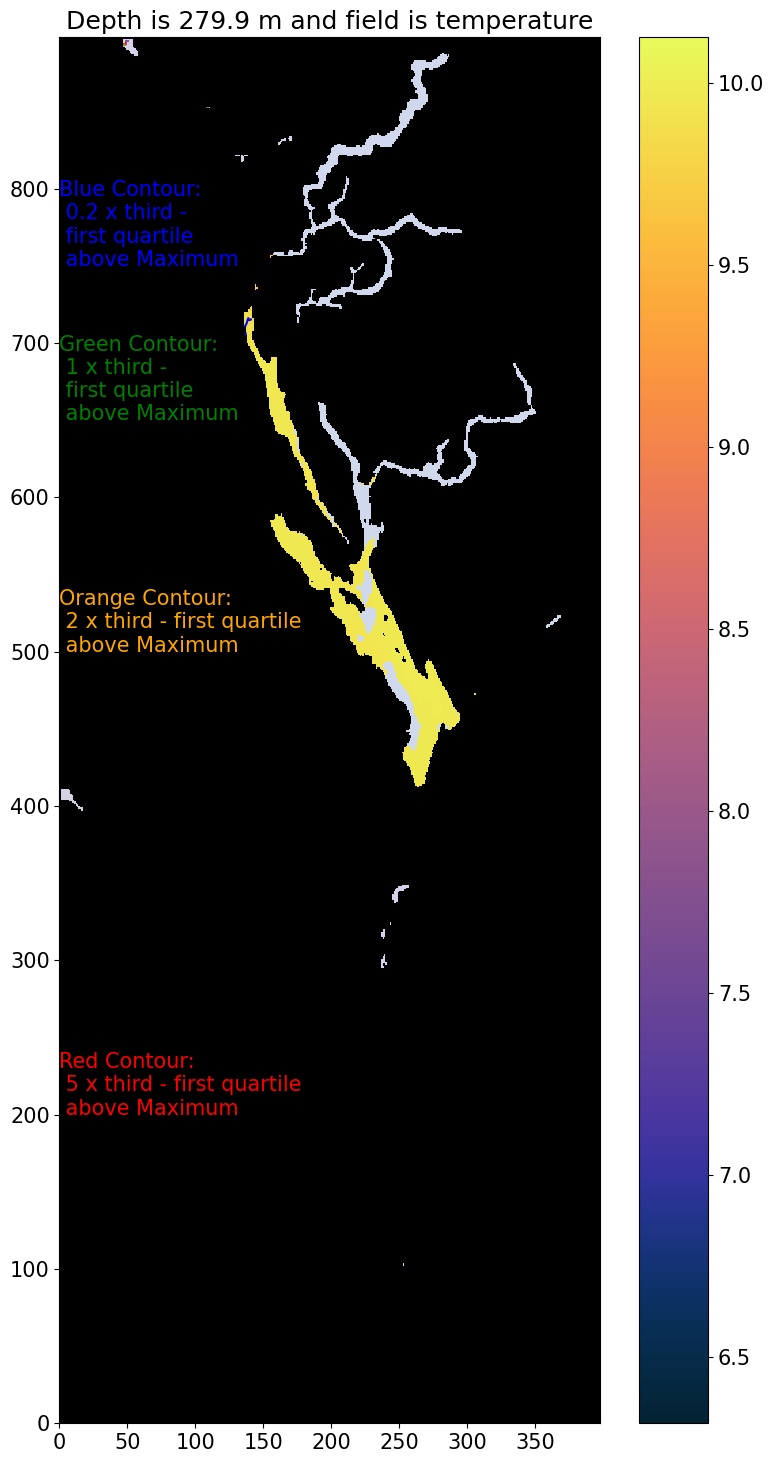

In [43]:
fig, ax = plt.subplots(1, 1, figsize=(10, 18))
ax.set_title(f'Depth is {deptht[dl*step].values:.1f} m and field is {nnames[kf]}')

ax.pcolormesh(tmask[dl*step, slice_y, slice_x], cmap='binary_r')
ax.pcolormesh(now_values[kf, dl], vmax=30, alpha=0.2, cmap=cm.haline)
if extreme == 'low':
    colours = ax.pcolormesh(np.ma.array(now[kf, dl], mask=1-min_mask[kf, dl]), vmin=vmin, vmax=vmax, cmap=cmap)
else:
    colours = ax.pcolormesh(np.ma.array(now[kf, dl], mask=1-max_mask[kf, dl]), vmin=vmin, vmax=vmax, cmap=cmap)
fig.colorbar(colours, ax=ax);
if extreme == 'low':
    ax.contour(extreme_low[kf, dl], [2, 5], colors=['orange', 'r'])
    ax.text(0, 500/step, 'Orange Contour:\n 2 x third - first quartile\n below Minimum', color='orange')
    ax.text(0, 200/step, 'Red Contour:\n 5 x third - first quartile\n below Minimum', color='r')
else:
    ax.contour(extreme_high[kf, dl], [0.2, 1, 2, 5], colors=['b', 'g', 'orange', 'r'])
    ax.text(0, 750/step, 'Blue Contour:\n 0.2 x third -\n first quartile\n above Maximum', color='b')
    ax.text(0, 650/step, 'Green Contour:\n 1 x third -\n first quartile\n above Maximum', color='g')
    ax.text(0, 500/step, 'Orange Contour:\n 2 x third - first quartile\n above Maximum', color='orange')
    ax.text(0, 200/step, 'Red Contour:\n 5 x third - first quartile\n above Maximum', color='r')

viz_tools.set_aspect(ax);

In [45]:
# a point 120, 250
def plot_cross(kf, dl, ii=int(500/step), js=int(160/step), je = int(290/step)):

    fig, ax = plt.subplots(1, 1)
    ax.plot(now_values[kf, dl, ii, js:je])
    ax.plot(median_values[kf, dl, ii, js:je], linewidth=3)
    ax.plot(low_values[kf, dl, ii, js:je], c='tab:orange')
    ax.plot(min_values[kf, dl, ii, js:je], c='tab:orange')
    ax.plot(high_values[kf, dl, ii, js:je], c='tab:orange')
    ax.plot(max_values[kf, dl, ii, js:je], c='tab:orange');
    ax.set_title(f'Across Strait, ii = {ii*step}, depth = {deptht[dl*step].values:.1f} m for {nnames[kf]}');

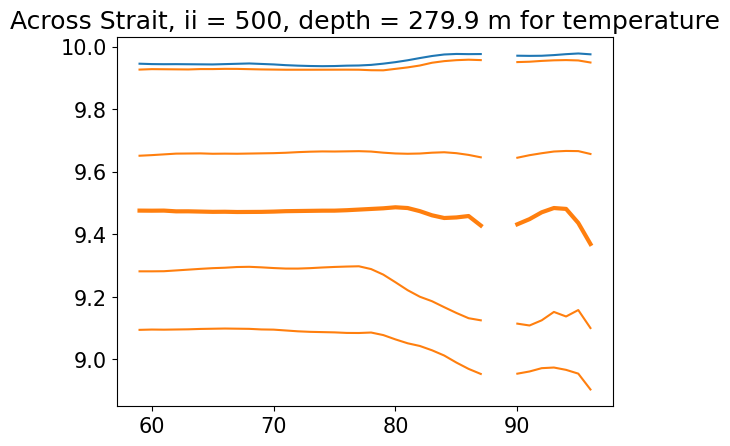

In [46]:
plot_cross(1, dl, ii=500)

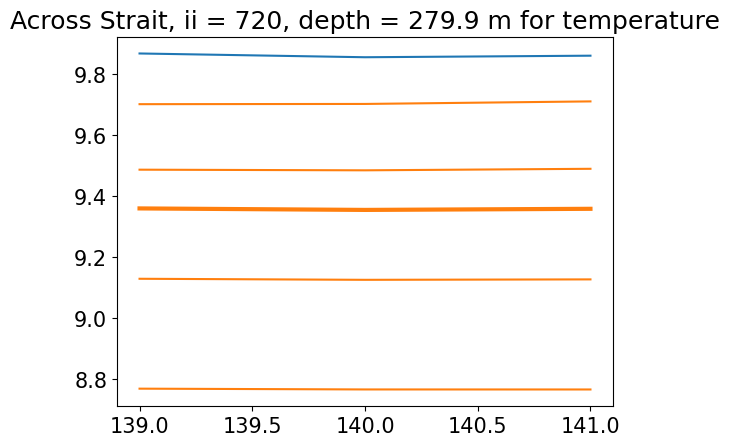

In [55]:
plot_cross(1, dl, ii=720, js=0, je=150)